# GlobalShop Direct : exploitation de la base transactionnelle
 
**Formation :** Data Analyst, Simplon Lyon 

**Auteure :** Ludivine Thinet

## Contexte
La direction marketing de GlobalShop Direct, plateforme e-commerce, nous confie l'exploitation de sa base transactionnelle `online_retail.csv`, qui contient l'historique brut de ses achats.

## Objectifs
- Nettoyer les transactions brutes
- Construire un profil par client selon la méthode RFM :
  - **Récence** : jours depuis le dernier achat
  - **Fréquence** : nombre total de commandes
  - **Montant** : total dépensé
- Réduire l'asymétrie des distributions et standardiser les variables
- Segmenter les clients par clustering et déterminer le nombre optimal de segments
- Interpréter et nommer chaque segment pour définir des personas marketing
- Préparer les éléments nécessaires au dashboard

## Plan
1. Import et chargement des données
2. Exploration (EDA)
3. Nettoyage des données
4. Construction du dataset RFM
5. Traitement de l'asymétrie (log1p)
6. Standardisation
7. Clustering K-Means
8. Clustering hiérarchique (CAH)
9. Comparaison des deux modèles
10. Réduction de dimension (PCA)
11. Profilage des segments et personas
12. Sauvegarde pour le dashboard

## 1. Import et chargement des données

### 1.1 Import des librairies
- `pandas` : manipulation des tableaux de données
- `numpy` : calculs numériques
- `matplotlib` et `seaborn` : visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Conversion et chargement du fichier en CSV

Le fichier fourni est en Excel. On le convertit une seule fois en CSV car il se lit beaucoup plus vite. Les identifiants sont lus comme du texte et la date comme une date. Les noms de colonnes sont traduits en français. `df_raw` garde les données brutes et le nettoyage se fait sur la copie `df`.

In [57]:
import os

# Conversion unique Excel -> CSV
if not os.path.exists("../data/online_retail.csv"):
    pd.read_excel("../data/Online_Retail.xlsx", dtype={"InvoiceNo": str, "StockCode": str}).to_csv("../data/online_retail.csv", index=False)

# Chargement
df_raw = pd.read_csv("../data/online_retail.csv", dtype={"InvoiceNo": str, "StockCode": str}, parse_dates=["InvoiceDate"])

# Traduction des noms de colonnes
df_raw = df_raw.rename(columns={
    "InvoiceNo": "numero_facture",
    "StockCode": "code_produit",
    "Description": "description",
    "Quantity": "quantite",
    "InvoiceDate": "date_facture",
    "UnitPrice": "prix_unitaire",
    "CustomerID": "id_client",
    "Country": "pays"
})

# Copie de travail
df = df_raw.copy()

## 2. Analyse exploratoire (EDA)

### 2.1 Structure du dataset

In [3]:
print(df.shape)
df.head(10)

(541909, 8)


,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   numero_facture  541909 non-null  object        
 1   code_produit    541909 non-null  object        
 2   description     540455 non-null  object        
 3   quantite        541909 non-null  int64         
 4   date_facture    541909 non-null  datetime64[ns]
 5   prix_unitaire   541909 non-null  float64       
 6   id_client       406829 non-null  float64       
 7   pays            541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Le dataset fait 541 909 lignes et 8 colonnes. Une ligne correspond à un produit dans une facture et pas à un client. Il faudra donc regrouper par `id_client` pour construire le RFM.

`id_client` est en float. C'est le signe qu'il y a des valeurs manquantes.

Les montants sont en livres sterling (£).

### 2.2 Statistiques descriptives

In [5]:
df.describe()

,quantite,date_facture,prix_unitaire,id_client
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Les données vont du 01/12/2010 au 09/12/2011. On a donc un peu plus d'un an d'historique.

`quantite` et `prix_unitaire` ont des minimums négatifs (-80 995 et -11 062). Ça ne correspond pas à des ventes. Ce sont sûrement des annulations, des retours ou des corrections. Les maximums (80 995 unités et un prix de 38 970 £) sont aussi à examiner.

La médiane de `quantite` est à 3 alors que la moyenne est à 9,55 et l'écart-type à 218. La distribution est très étirée vers la droite.

Les statistiques de `id_client` n'ont pas de sens. C'est un identifiant.

### 2.3 Valeurs manquantes

In [6]:
manquants = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pourcentage": (df.isna().mean() * 100).round(2)
})
manquants

,nb_manquants,pourcentage
numero_facture,0,0.00
code_produit,0,0.00
description,1454,0.27
quantite,0,0.00
date_facture,0,0.00
prix_unitaire,0,0.00
id_client,135080,24.93
pays,0,0.00


Deux colonnes concernées :
- **`id_client`** : 135 080 valeurs manquantes (24,93 %). Point bloquant : une transaction sans client ne peut pas être rattachée à un profil RFM.
- **`description`** : 1 454 valeurs manquantes (0,27 %). Sans impact, cette colonne n'intervient pas dans le calcul du RFM.

### 2.4 Doublons

In [7]:
print("Lignes dupliquées :", df.duplicated().sum())

Lignes dupliquées : 5268


5 268 lignes sont strictement identiques soit environ 1 % du dataset. Même facture, même produit, même quantité et même horodatage. Ce sont très probablement des erreurs d'enregistrement. Si on les garde, elles gonflent le Montant des clients concernés.

### 2.5 Quantités négatives

`describe()` a révélé des quantités négatives. On examine ces lignes.

In [8]:
df[df["quantite"] <= 0].head(10)

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


Toutes ces lignes ont un `numero_facture` commençant par "C", alors que les factures classiques sont numériques. La documentation du dataset confirme que "C" correspond à une annulation.

On voit aussi un code produit "D" (Discount) qui est une remise et pas un produit.

In [58]:
#On vérifie sur tout le dataset si les quantités négatives sont toutes des annulations.
annulations = df["numero_facture"].str.startswith("C")
quantite_neg = df["quantite"] <= 0

print("Factures d'annulation :", annulations.sum())
print("Quantités <= 0 :", quantite_neg.sum())
print("Annulations avec quantité <= 0 :", (annulations & quantite_neg).sum())
print("Quantités <= 0 hors annulations :", (~annulations & quantite_neg).sum())

Factures d'annulation : 9288
Quantités <= 0 : 10624
Annulations avec quantité <= 0 : 9288
Quantités <= 0 hors annulations : 1336


Les 9 288 annulations ont toutes une quantité négative. Le "C" et le signe moins vont donc ensemble.

Par contre il reste 1 336 lignes avec une quantité négative qui ne sont pas des annulations. On regarde d'où elles viennent.

In [10]:
df[~annulations & quantite_neg].head(10)

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [59]:
#Verification si toutes les lignes sont sans id_client
neg_hors_annul = df[~annulations & quantite_neg]

print("Sans id_client :", neg_hors_annul["id_client"].isna().sum())
print("Prix à 0 :", (neg_hors_annul["prix_unitaire"] == 0).sum())

Sans id_client : 1336
Prix à 0 : 1336


Sur ces 1 336 lignes, aucune n'a d'id client et toutes ont un prix à 0. Ce ne sont donc pas des ventes mais plutôt des ajustements de stock internes (casse, perte, inventaire...).
Elles partiront quand on supprimera les lignes sans id client.

### 2.6 Prix nuls ou négatifs

In [12]:
prix_neg = df["prix_unitaire"] < 0
prix_nul = df["prix_unitaire"] == 0

print("Prix négatifs :", prix_neg.sum())
print("Prix à 0 :", prix_nul.sum())
print("Prix à 0 hors quantités négatives déjà vues :", (prix_nul & ~quantite_neg).sum())

Prix négatifs : 2
Prix à 0 : 2515
Prix à 0 hors quantités négatives déjà vues : 1179


In [13]:
df[prix_neg]

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


Les 2 prix négatifs sont des écritures comptables ("Adjust bad debt", une régularisation de créance impayée), avec une facture qui commence par "A" et sans id client. Rien à voir avec une vente, et elles partiront avec la suppression des id clients manquants.

In [14]:
# On regarde les prix à 0 qu'on n'a pas encore expliqués 
prix_nul_pos = df[prix_nul & ~quantite_neg]

print("Sans id_client :", prix_nul_pos["id_client"].isna().sum())
prix_nul_pos.head(10)

Sans id_client : 1139


,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.0,NaN,United Kingdom


In [15]:
# On regarde les prix à 0 qui ont un vrai client car seulement 1139 sur 1179 sont sans id_client. 
prix_nul_pos[prix_nul_pos["id_client"].notna()].head(10)

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [16]:
# Pour chaque facture contenant un article à 0 € avec un vrai client : combien d'articles payants contient-elle ?
factures_prix_nul = prix_nul_pos[prix_nul_pos["id_client"].notna()]["numero_facture"].unique()

factures = df[df["numero_facture"].isin(factures_prix_nul)]
factures.groupby("numero_facture")["prix_unitaire"].apply(lambda x: (x > 0).sum()).value_counts()

prix_unitaire
1      5
0      4
2      3
6      2
3      2
20     2
7      2
16     1
13     1
34     1
10     1
4      1
57     1
5      1
24     1
9      1
22     1
21     1
169    1
28     1
62     1
Name: count, dtype: int64

- **2 prix négatifs** : des écritures comptables ("Adjust bad debt"), sans id client.
- **2 515 prix à 0** :
  - 1 336 sont les ajustements de stock déjà vus (quantité négative, pas de client) 
  - 1 139 ont une quantité positive mais pas de client, même profil d'ajustement interne 
  - 40 lignes ont un vrai produit et un vrai client. Elles sont réparties sur 34 factures car certaines factures ont plusieurs articles à 0. 30 de ces factures contiennent aussi des articles payants. Ce sont probablement des articles offerts avec une commande. Les 4 autres factures ne contiennent que des articles à 0 et on ne sait pas d'où elles viennent.
  - Presque tout partira avec la suppression des id clients manquants. Les 40 lignes restantes n'ajoutent rien au montant : à décider au nettoyage.

### 2.7 Codes produits particuliers

On a croisé des codes produits avec lettre ("D" pour Discount, "B" pour bad debt). Les codes normaux commencent par 5 chiffres (ex. 85123A). On liste ceux qui ne suivent pas ce format.

In [17]:
# On cherche les codes produits qui ne commencent pas par 5 chiffres, avec leur description et leur nombre de lignes
codes_speciaux = df[~df["code_produit"].str.match(r"^\d{5}")]

codes_speciaux.groupby("code_produit").agg(
    description=("description", "first"),
    nb_lignes=("code_produit", "size")
).sort_values("nb_lignes", ascending=False)

,description,nb_lignes
code_produit,,
POST,POSTAGE,1256
DOT,DOTCOM POSTAGE,710
M,Manual,571
C2,CARRIAGE,144
D,Discount,77
S,SAMPLES,63
BANK CHARGES,Bank Charges,37
AMAZONFEE,AMAZON FEE,34
CRUK,CRUK Commission,16


Les codes qui ne commencent pas par 5 chiffres se rangent en plusieurs familles :
- **Frais de livraison** : POST, DOT, C2 (carriage). Ce sont des frais d'envoi, pas des produits.
- **Frais et commissions** : BANK CHARGES, AMAZONFEE, CRUK (commission versée à une association). Ce sont des coûts, pas des achats.
- **Ajustements** : D (remise), B (bad debt), S (échantillons), M et m (saisie manuelle, on ne sait pas ce qu'il y a derrière).
- **Bons cadeaux** : gift_0001_XX. C'est un vrai achat mais d'un bon et pas d'un produit.
- **Vrais produits avec un code non standard** : les DCGS (sacs de fête, colliers pour chien...) et PADS. Quelques DCGS n'ont pas de description ou juste "ebay", donc plutôt des ajustements.

Le format "5 chiffres" ne suffit pas pour repérer les intrus car il attrape aussi de vrais produits. On triera au nettoyage.

In [18]:
# Les frais de livraison sont-ils facturés au client ? On regarde leur prix et s'ils ont un client
livraison = df[df["code_produit"].isin(["POST", "DOT", "C2"])]

livraison.groupby("code_produit").agg(
    nb_lignes=("prix_unitaire", "size"),
    prix_min=("prix_unitaire", "min"),
    prix_median=("prix_unitaire", "median"),
    prix_max=("prix_unitaire", "max"),
    sans_client=("id_client", lambda x: x.isna().sum())
)

,nb_lignes,prix_min,prix_median,prix_max,sans_client
code_produit,,,,,
C2,144,0.0,50.00,150.00,10
DOT,710,0.0,184.94,4505.17,694
POST,1256,0.0,18.00,8142.75,60


J'ai vérifié les frais de livraison (POST, DOT, C2) : ils ont un prix positif sur la facture du client donc c'est bien le client qui les paie (le port est parfois offert, prix à 0, mais c'est rare). Les DOT n'ont presque jamais de client et partiront au nettoyage. Pour POST et C2, il faudra décider si on les garde dans le montant : c'est de l'argent dépensé, mais pas un achat de produit. Quelques prix max sont aberrants (8 142 pour un POST).

### 2.8 Répartition par pays

In [19]:
# On regarde d'où viennent les clients : nombre de pays et part de chacun dans les lignes
print("Nombre de pays :", df["pays"].nunique())
(df["pays"].value_counts(normalize=True) * 100).round(2).head(10)

Nombre de pays : 38


pays
United Kingdom    91.43
Germany            1.75
France             1.58
EIRE               1.51
Spain              0.47
Netherlands        0.44
Belgium            0.38
Switzerland        0.37
Portugal           0.28
Australia          0.23
Name: proportion, dtype: float64

In [20]:
# Même chose mais en comptant les clients distincts par pays, et plus les lignes
clients_pays = df.groupby("pays")["id_client"].nunique().sort_values(ascending=False)

print("Nombre total de clients :", df["id_client"].nunique())
(clients_pays / clients_pays.sum() * 100).round(2).head(10)

Nombre total de clients : 4372


pays
United Kingdom    90.18
Germany            2.17
France             1.99
Spain              0.71
Belgium            0.57
Switzerland        0.48
Portugal           0.43
Italy              0.34
Finland            0.27
Austria            0.25
Name: id_client, dtype: float64

Il y a 38 pays mais le Royaume-Uni écrase tout. Il représente 91 % des lignes et 90 % des clients (4 372 clients au total). GlobalShop Direct est surtout une entreprise britannique avec quelques clients à l'international.

Les deux comptages ne donnent pas le même classement. L'Irlande (EIRE) est 4e en nombre de lignes mais n'est même pas dans le top 10 en nombre de clients. Elle a très peu de clients qui commandent énormément. Ce sont probablement des grossistes. Ils risquent de ressortir comme des extrêmes au clustering.

### 2.9 Activité dans le temps

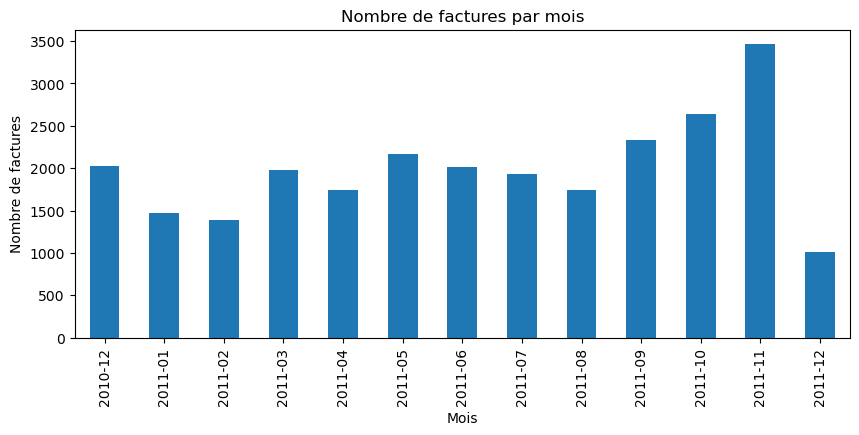

In [21]:
# On compte le nombre de factures par mois pour voir comment l'activité évolue sur l'année
factures_mois = df.groupby(df["date_facture"].dt.to_period("M"))["numero_facture"].nunique()

factures_mois.plot(kind="bar", figsize=(10, 4), title="Nombre de factures par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de factures")
plt.show()

L'activité est stable de janvier à août, entre 1 400 et 2 200 factures par mois. Elle augmente à partir de septembre jusqu'à un pic en novembre avec près de 3 500 factures. C'est la préparation de Noël.. Décembre 2011 paraît bas mais le mois s'arrête le 9. 1 000 factures en 9 jours, c'est en fait un rythme élevé.

Point d'attention pour la Récence. Avec ce pic de fin d'année, beaucoup de clients auront acheté récemment. Ça inclut des acheteurs occasionnels de Noël. Une bonne Récence ne voudra pas forcément dire client fidèle.

### 2.10 Valeurs extrêmes

In [22]:
# On regarde les 10 lignes avec les plus grosses quantités pour voir si ce sont de vraies commandes ou des erreurs
df.sort_values("quantite", ascending=False).head(10)

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,2011-06-09 15:04:00,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom


In [23]:
# On regarde toutes les lignes des deux clients aux quantités énormes, pour voir ce qui s'est passé ensuite
df[df["id_client"].isin([16446, 12346])].sort_values(["id_client", "date_facture"])

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


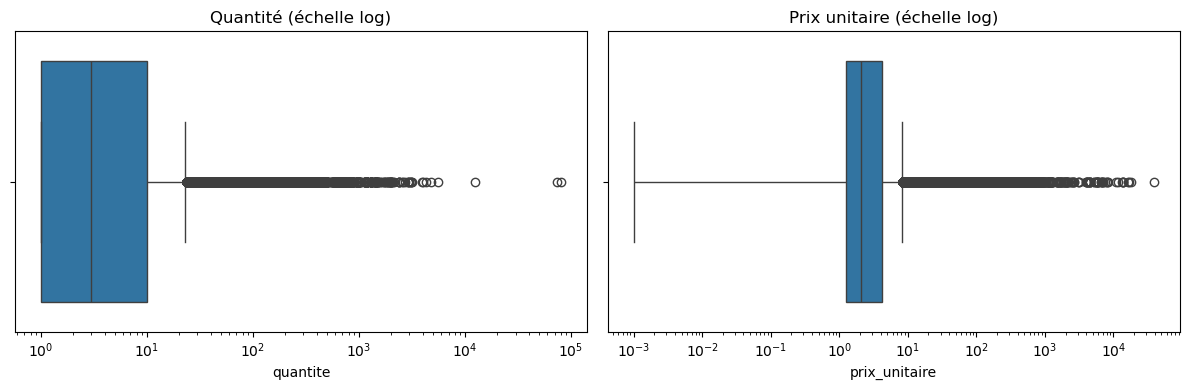

In [24]:
# Boxplots des quantités et des prix (valeurs positives), en échelle log pour voir à la fois la boîte et les extrêmes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df.loc[df["quantite"] > 0, "quantite"], ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Quantité (échelle log)")

sns.boxplot(x=df.loc[df["prix_unitaire"] > 0, "prix_unitaire"], ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Prix unitaire (échelle log)")

plt.tight_layout()
plt.show()

L'échelle log sert seulement pour l'affichage. Les données ne sont pas modifiées.

La plupart des quantités sont entre 1 et 10 et la plupart des prix entre 1 et 5 £. On voit par contre une longue traînée de valeurs élevées. Pour les quantités, elle reste continue jusqu'à environ 5 000. Au-delà, il y a seulement quelques points isolés. Ce sont les cas suspects.

Les deux quantités les plus élevées (74 215 et 80 995) ont été annulées 12 à 16 minutes après la commande. Ça ressemble donc à des erreurs de saisie corrigées rapidement.

Le problème, c'est que l'annulation ne supprime pas la commande d'origine. Elle reste dans les données. Si on supprime seulement les lignes "C", ces deux clients se retrouvent avec des montants de 77 000 £ et 168 000 £ alors qu'ils ont en réalité très peu acheté. Le problème peut donc concerner d'autres commandes. On vérifie ça en 2.11.

Pour les autres grosses quantités, entre 3 000 et 5 000 unités, on a une suite continue de valeurs. Elles concernent surtout de petits articles à quelques centimes et donnent des montants cohérents. Par exemple, 4 800 planeurs à 0,21 £ donnent environ 1 000 £. Ça semble donc plausible pour des commandes de grossistes. On vérifiera en 2.11 si ces commandes ont aussi été annulées.

In [25]:
# On regarde les 10 lignes avec les prix unitaires les plus élevés pour voir si ce sont de vrais produits
df.sort_values("prix_unitaire", ascending=False).head(10)

,numero_facture,code_produit,description,quantite,date_facture,prix_unitaire,id_client,pays
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


Les prix les plus élevés ne correspondent jamais à des produits. Ce sont des frais Amazon, des régularisations comptables et des saisies manuelles (« M »). La plupart n'ont pas de client et seront supprimés lors du nettoyage. Le seul avec un client correspond à une annulation de saisie manuelle à 38 970 £ (client 15098). L'opération d'origine est peut-être encore présente dans les données. À vérifier en 2.11.

### 2.11 Annulations et achats d'origine

Les valeurs extrêmes ont montré que les annulations ne suppriment pas l'achat d'origine : la commande reste dans les données. On vérifie si c'est le cas pour toutes les annulations.

In [26]:
# Pour chaque annulation, on cherche l'achat d'origine : même client, même produit, même quantité en positif
annul = df[annulations & df["id_client"].notna()].copy()
achats = df[~annulations & df["id_client"].notna()]

annul["quantite_positive"] = -annul["quantite"]

correspondances = annul.merge(
    achats[["id_client", "code_produit", "quantite"]].drop_duplicates(),
    left_on=["id_client", "code_produit", "quantite_positive"],
    right_on=["id_client", "code_produit", "quantite"],
    how="left",
    indicator=True
)

print("Annulations avec client :", len(annul))
correspondances["_merge"].value_counts()

Annulations avec client : 8905


_merge
left_only     5639
both          3266
right_only       0
Name: count, dtype: int64

In [27]:
# On regarde quelques annulations sans achat correspondant pour comprendre pourquoi on ne les retrouve pas
correspondances[correspondances["_merge"] == "left_only"].head(10)

,numero_facture,code_produit,description,quantite_x,date_facture,prix_unitaire,id_client,pays,quantite_positive,quantite_y,_merge
0,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,1,NaN,left_only
1,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,1,NaN,left_only
2,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,12,NaN,left_only
3,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,24,NaN,left_only
4,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,24,NaN,left_only
5,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,24,NaN,left_only
6,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,12,NaN,left_only
7,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,12,NaN,left_only
8,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,24,NaN,left_only
9,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,6,NaN,left_only


In [28]:
# On classe les annulations sans achat correspondant selon la raison probable
sans_achat = correspondances[correspondances["_merge"] == "left_only"]

# Les paires client + produit qu'on trouve dans les achats (peu importe la quantité)
paires_achetees = achats[["id_client", "code_produit"]].drop_duplicates()
sans_achat = sans_achat.merge(paires_achetees, on=["id_client", "code_produit"], how="left", indicator="deja_achete")

code_special = ~sans_achat["code_produit"].str.match(r"^\d{5}")
produit_achete = sans_achat["deja_achete"] == "both"

print("Code particulier (remise, saisie manuelle...) :", code_special.sum())
print("Produit acheté mais quantité différente (annulation partielle) :", (~code_special & produit_achete).sum())
print("Produit jamais acheté dans le dataset (achat hors période) :", (~code_special & ~produit_achete).sum())

Code particulier (remise, saisie manuelle...) : 276
Produit acheté mais quantité différente (annulation partielle) : 4670
Produit jamais acheté dans le dataset (achat hors période) : 693


Sur les 8 905 annulations avec un client :
- 3 266 retrouvent leur achat d'origine à l'identique (même client, même produit, même quantité) : annulations totales.
- 4 670 portent sur un produit que le client a bien acheté, mais pas dans la même quantité : ce sont surtout des retours partiels.
- 693 portent sur un produit jamais acheté dans nos données : l'achat d'origine date sûrement d'avant décembre 2010.
- 276 sont des codes particuliers (remises, saisies manuelles).

Conclusion : supprimer seulement les lignes "C" laisse dans les données des achats qui ont été annulés ou retournés, et gonfle le montant de beaucoup de clients. Il faudra en tenir compte au nettoyage.

### 2.12 Synthèse de l'EDA

| Problème | Ce qu'on a vu | Ce qu'on fera au nettoyage |
|---|---|---|
| id client manquant | 135 080 lignes (25 %) | Suppression : impossible de rattacher ces lignes à un client |
| Doublons | 5 268 lignes identiques | Suppression |
| Annulations | 8 905 avec client : 3 266 totales, 4 670 partielles, 693 hors période, 276 codes particuliers | Annulations totales : suppression de l'annulation et de l'achat d'origine. Annulations partielles : gardées, déduites dans un montant net (achats - retours). Hors période : suppression |
| Quantités négatives hors annulations | 1 336 ajustements de stock, sans client | Partent avec les id manquants |
| Prix négatifs ou à 0 | Écritures comptables et ajustements, presque tous sans client. 40 articles probablement offerts | On ne garde que les prix > 0 |
| Codes non-produits | Frais de port, frais Amazon, commissions, remises, saisies manuelles, bons cadeaux... Quelques vrais produits avec un code non standard (DCGS, PADS) | Suppression d'une liste précise de codes non-produits. Les DCGS et PADS restent |
| Valeurs extrêmes | 2 commandes géantes annulées juste après. Des gros grossistes au comportement réel | Les commandes géantes partent avec les annulations totales. Les grossistes restent |
| Pays | Royaume-Uni à 90 %. L'Irlande : très peu de clients mais énormément de commandes | On garde tous les pays : on segmente sur le comportement d'achat, pas sur la géographie |
| Saisonnalité | Pic d'activité de septembre à novembre (Noël) | À garder en tête : une bonne Récence ne veut pas forcément dire client fidèle |

## 3. Nettoyage des données

On applique les décisions prises dans la synthèse de l'EDA, dans cet ordre. À chaque étape, on note le nombre de lignes supprimées.

### 3.1 Suppression des lignes sans id client

In [29]:
# On supprime les lignes sans id client, puis on passe l'id en entier (plus de NaN, donc plus besoin du float)
avant = len(df)

df = df.dropna(subset=["id_client"])
df["id_client"] = df["id_client"].astype(int)

print(f"Lignes supprimées : {avant - len(df)}")
print(f"Lignes restantes : {len(df)}")

Lignes supprimées : 135080
Lignes restantes : 406829


135 080 lignes supprimées, il en reste 406 829.

### 3.2 Suppression des doublons

In [30]:
# On supprime les lignes strictement identiques (on garde la première occurrence)
avant = len(df)

df = df.drop_duplicates()

print(f"Lignes supprimées : {avant - len(df)}")
print(f"Lignes restantes : {len(df)}")

Lignes supprimées : 5225
Lignes restantes : 401604


5 225 doublons supprimés (les 43 autres n'avaient pas d'id client et sont partis à l'étape d'avant). Il reste 401 604 lignes.

### 3.3 Suppression des codes non-produits

On retire les lignes qui ne sont pas des achats de produits : frais de port, frais et commissions, ajustements et bons cadeaux. Les DCGS et PADS sont de vrais produits, on les garde.

In [31]:
# On supprime les codes qui ne sont pas des produits (liste précise, pour ne pas toucher aux DCGS et PADS)
codes_a_retirer = ["POST", "DOT", "C2", "BANK CHARGES", "AMAZONFEE", "CRUK", "M", "m", "B", "D", "S"]
est_non_produit = df["code_produit"].isin(codes_a_retirer) | df["code_produit"].str.startswith("gift_0001")

avant = len(df)
print(df.loc[est_non_produit, "code_produit"].value_counts())

df = df[~est_non_produit]

print(f"\nLignes supprimées : {avant - len(df)}")
print(f"Lignes restantes : {len(df)}")

code_produit
POST            1196
M                460
C2               134
D                 77
DOT               16
CRUK              16
BANK CHARGES      12
Name: count, dtype: int64

Lignes supprimées : 1911
Lignes restantes : 399693


1 911 lignes supprimées, surtout des frais de port (POST, C2) et des saisies manuelles (M). Les autres codes de la liste (échantillons, frais Amazon, bons cadeaux...) n'avaient pas d'id client et étaient déjà partis. Il reste 399 693 lignes.

### 3.4 Suppression des annulations hors période

Les annulations dont l'achat d'origine n'est pas dans nos données (achat d'avant décembre 2010) sont supprimées : elles retireraient de l'argent au client pour un achat qu'on n'a jamais compté.

In [32]:
# On repère les annulations portant sur un produit que le client n'a jamais acheté dans nos données, puis on les supprime
est_annulation = df["numero_facture"].str.startswith("C")

paires_achetees = df.loc[~est_annulation, ["id_client", "code_produit"]].drop_duplicates()
paires_achetees["deja_achete"] = True

df = df.merge(paires_achetees, on=["id_client", "code_produit"], how="left")
hors_periode = est_annulation.values & df["deja_achete"].isna()

avant = len(df)
df = df[~hors_periode].drop(columns="deja_achete")

print(f"Lignes supprimées : {avant - len(df)}")
print(f"Lignes restantes : {len(df)}")

Lignes supprimées : 692
Lignes restantes : 399001


692 annulations hors période supprimées (une de moins que dans l'EDA car elle portait sur un code non-produit déjà retiré). Il reste 399 001 lignes.

### 3.5 Suppression des annulations totales

Quand une commande est annulée en entier, le client n'a rien acheté. On retrouve l'achat d'origine de chaque annulation (même client, même produit, même quantité, passé avant l'annulation) et on supprime les deux lignes. Les annulations partielles restent : elles seront déduites au calcul du montant.

In [33]:
# Pour chaque annulation, on retrouve l'achat d'origine juste avant, puis on supprime les deux lignes
df = df.reset_index(drop=True)
est_annulation = df["numero_facture"].str.startswith("C")

colonnes = ["id_client", "code_produit", "quantite", "date_facture"]
annul = df.loc[est_annulation, colonnes].reset_index()
annul["quantite"] = -annul["quantite"]
achats = df.loc[~est_annulation, colonnes].reset_index()

paires = pd.merge_asof(
    annul.sort_values("date_facture"),
    achats.sort_values("date_facture"),
    on="date_facture",
    by=["id_client", "code_produit", "quantite"],
    direction="backward",
    suffixes=("_annul", "_achat")
)

paires = paires.dropna(subset=["index_achat"]).drop_duplicates(subset="index_achat")
a_supprimer = list(paires["index_annul"]) + list(paires["index_achat"].astype(int))

avant = len(df)
df = df.drop(index=a_supprimer)

print(f"Annulations totales retrouvées : {len(paires)}")
print(f"Lignes supprimées : {avant - len(df)}")
print(f"Lignes restantes : {len(df)}")

Annulations totales retrouvées : 2805
Lignes supprimées : 5610
Lignes restantes : 393391


2 805 annulations totales retrouvées avec leur achat d'origine : 5 610 lignes supprimées (l'achat et l'annulation). Moins que les 3 266 de l'EDA car ici j'ai imposé que l'achat soit avant l'annulation et qu'un achat ne serve qu'une fois. Les annulations restantes seront déduites dans le montant net. Il reste 393 391 lignes.

### 3.6 Filtrage des prix

On ne garde que les lignes avec un prix strictement positif : ça retire les articles offerts (prix à 0), qui ne sont pas de vrais achats.

In [34]:
# On garde uniquement les lignes avec un prix supérieur à 0
avant = len(df)

df = df[df["prix_unitaire"] > 0]

print(f"Lignes supprimées : {avant - len(df)}")
print(f"Lignes restantes : {len(df)}")

Lignes supprimées : 34
Lignes restantes : 393357


34 lignes à prix nul supprimées (les articles offerts restants). Il reste 393 357 lignes. Les 6 autres vu dans l'EDA on été supprimés dans les sections précédentes. 

### 3.7 Calcul du montant par ligne

Montant de chaque ligne = quantité × prix unitaire. Il est négatif pour les annulations partielles restantes : elles seront déduites automatiquement au regroupement par client.

In [37]:
# On calcule le montant de chaque ligne (négatif pour les annulations restantes)
df["montant_ligne"] = df["quantite"] * df["prix_unitaire"]

df[["quantite", "prix_unitaire", "montant_ligne"]].describe()

,quantite,prix_unitaire,montant_ligne
count,393357.000000,393357.000000,393357.000000
mean,12.431133,2.866479,20.956677
std,42.108261,3.991397,68.593290
min,-960.000000,0.001000,-2432.700000
25%,2.000000,1.250000,4.500000
50%,6.000000,1.950000,11.700000
75%,12.000000,3.750000,19.800000
max,4800.000000,649.500000,7144.720000


- **Quantités** : le max est maintenant de 4 800 (contre 80 995 au départ) : les commandes géantes annulées ont bien disparu. Le min à -960 correspond aux annulations restantes, qui seront déduites.
- **Prix** : de 0,001 £ à 649,50 £, contre -11 062 à 38 970 £ au départ. Plus de frais ni d'écritures comptables.
- **Montant par ligne** : médiane de 11,70£ , mais la moyenne (20,96 £) et le max (7 144 £) montrent qu'il reste une asymétrie avec quelques grosses lignes de grossistes. C'est normal et ce sera traité avec log1p plus tard.

### 3.8 Bilan du nettoyage

In [39]:
# Comparaison avant / après nettoyage : lignes, clients et factures
bilan = pd.DataFrame({
    "avant": [len(df_raw), df_raw["id_client"].nunique(), df_raw["numero_facture"].nunique()],
    "après": [len(df), df["id_client"].nunique(), df["numero_facture"].nunique()]
}, index=["lignes", "clients", "factures"])

bilan["supprimé (%)"] = ((1 - bilan["après"] / bilan["avant"]) * 100).round(2)
bilan

,avant,après,supprimé (%)
lignes,541909,393357,27.41
clients,4372,4324,1.10
factures,25900,20729,19.97


Le nettoyage a retiré 27 % des lignes. Cela vient surtout des ID clients manquants qui représentent à eux seuls 25 % des lignes supprimées.
Côté clients, on n'en perd que 48. Ce sont ceux dont toutes les lignes ont été supprimées. Par exemple des clients qui n'avaient que des commandes annulées en entier.

20 % des factures ont également disparu. Il s'agit des factures sans client, des factures d'annulation totale et de leurs achats d'origine.

Il reste 393 357 lignes et 4 324 clients. Le dataset est maintenant prêt pour la construction du RFM.

## 4. Construction du dataset RFM

### 4.1 Date de référence

Pour calculer la Récence, il faut une date de départ. On prend le lendemain de la dernière facture, comme si on faisait l'analyse le 10 décembre 2011. C'est ce qui se fait en général en RFM. Ça décale juste tout le monde d'un jour, donc ça ne change rien aux écarts entre clients.

In [41]:
# Date de référence : le lendemain de la dernière facture, à minuit (pour compter en jours entiers)
date_reference = df["date_facture"].max().normalize() + pd.Timedelta(days=1)
print("Date de référence :", date_reference)

Date de référence : 2011-12-10 00:00:00


### 4.2 Calcul de la Récence, la Fréquence et le Montant

On regroupe toutes les lignes par client. La Récence et la Fréquence se calculent seulement sur les achats (pas sur les retours). Le Montant, lui, se calcule sur toutes les lignes : les retours viennent se déduire des achats.

In [42]:
# On regroupe par client pour calculer R, F et M
achats = df[~df["numero_facture"].str.startswith("C")]

# Récence et Fréquence : uniquement sur les achats
rfm = achats.groupby("id_client").agg(
    derniere_date=("date_facture", "max"),
    frequence=("numero_facture", "nunique")
)
rfm["recence"] = (date_reference - rfm["derniere_date"].dt.normalize()).dt.days

# Montant : sur toutes les lignes, retours compris
rfm["montant"] = df.groupby("id_client")["montant_ligne"].sum()

rfm = rfm[["recence", "frequence", "montant"]]
print(rfm.shape)
rfm.head()

(4324, 3)


,recence,frequence,montant
id_client,,,
12347,3,7,4310.00
12348,76,4,1437.24
12349,19,1,1457.55
12350,311,1,294.40
12352,37,6,1265.41


On obtient un tableau de 4 324 clients, un par ligne, avec leur Récence, leur Fréquence et leur Montant. Par exemple, le client 12347 a acheté il y a 3 jours, a passé 7 commandes et a dépensé 4 310 £ au total.

### 4.3 Retrait des clients au montant nul ou négatif

Si le montant d'un client est à 0 ou en dessous, c'est qu'au final il n'a rien acheté (ses retours compensent ou dépassent ses achats). On les retire. En plus, le log de la partie 5 ne marche pas sur des valeurs négatives.

In [43]:
# On regarde combien de clients ont un montant nul ou négatif, puis on les retire
print("Clients avec un montant <= 0 :", (rfm["montant"] <= 0).sum())

rfm = rfm[rfm["montant"] > 0]
print("Clients restants :", len(rfm))

Clients avec un montant <= 0 : 3
Clients restants : 4321


Seulement 3 clients avaient un montant nul ou négatif : des cas où un retour porte sur un achat fait avant décembre 2010 qu'on ne voit pas dans nos données. On les retire, il reste 4 321 clients.

### 4.4 Vérification sur quelques clients

On vérifie à la main que les calculs sont justes, sur les deux clients des commandes géantes annulées.

In [44]:
# Les deux clients des commandes géantes annulées : sont-ils bien traités ?
print("Client 12346 présent :", 12346 in rfm.index)
rfm.loc[[16446]]

Client 12346 présent : False


,recence,frequence,montant
id_client,,,
16446,206,1,2.9


- Le client 12346 a bien disparu : sa seule commande avait été annulée en entier, donc au final il n'a rien acheté.
- Le client 16446 n'a plus que ses deux brosses de mai : 1 commande, 2,90 £, dernier achat il y a 206 jours. Sans le nettoyage des annulations, il aurait eu 168 000 £ et une Récence de 1 jour.

Les calculs sont bons.

### 4.5 Aperçu du dataset RFM

In [46]:
# Statistiques des trois variables RFM
rfm.describe().round(2)

,recence,frequence,montant
count,4321.00,4321.00,4321.00
mean,93.30,4.23,1907.77
std,100.24,7.57,8286.98
min,1.00,1.00,2.90
25%,18.00,1.00,300.05
50%,51.00,2.00,652.74
75%,144.00,5.00,1611.38
max,374.00,203.00,278742.02


In [47]:
# On regarde les 10 clients qui ont dépensé le plus, avec leur pays, pour vérifier que ce sont de vrais gros clients
pays_client = df.groupby("id_client")["pays"].first()

rfm.join(pays_client).sort_values("montant", ascending=False).head(10)

,recence,frequence,montant,pays
id_client,,,,
14646,2,72,278742.02,Netherlands
18102,1,60,259657.30,United Kingdom
17450,9,45,189575.53,United Kingdom
14911,2,195,128828.56,EIRE
12415,25,19,123638.18,Australia
14156,10,54,113690.02,EIRE
17511,3,30,88193.23,United Kingdom
16684,5,28,65920.12,United Kingdom
13694,4,50,63067.14,United Kingdom


On a maintenant notre dataset final : 4 321 clients, une ligne par client, avec leur Récence, leur Fréquence et leur Montant. C'est lui qui part en partie 5.

Ce qu'on remarque avec le describe :
- **Récence** : de 1 à 374 jours. La moitié des clients a acheté il y a moins de 51 jours, mais la moyenne monte à 93 parce que certains ne sont pas revenus depuis longtemps.
- **Fréquence** : au moins un quart des clients n'a commandé qu'une fois, la médiane est à 2. Mais certains montent jusqu'à 203 commandes.
- **Montant** : médiane à 653 £, moyenne à 1 908 £, et un max à 278 742 £. L'écart-type est même plus grand que la moyenne.

Sur les trois variables, la moyenne est bien au-dessus de la médiane. Les distributions sont très asymétriques, surtout le Montant : une petite poignée de clients est très loin des autres.

On a vérifié ces gros clients : ils sont réels. Ils ont tous beaucoup de commandes (19 à 195) et ont presque tous acheté il y a moins de 10 jours. Ce sont sûrement des grossistes ou des revendeurs. On retrouve d'ailleurs les deux clients irlandais repérés en EDA et 4 clients sur 10 du top sont étrangers, alors que l'étranger ne représente que 10 % de la clientèle.

On les garde, ce ne sont pas des erreurs. Par contre, cette asymétrie va poser problème au clustering (K-Means calcule des distances, et ces clients écraseraient tout le reste). C'est ce qu'on traite en partie 5.

## 5. Traitement de l'asymétrie

### 5.1 Distributions avant transformation

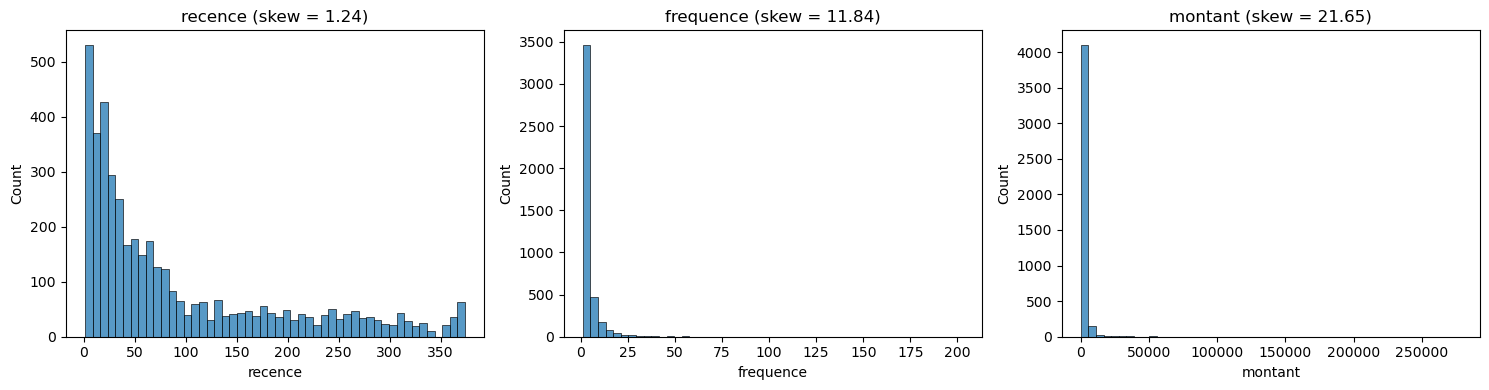

In [49]:
# Histogrammes de R, F et M pour voir leur forme, avec le coefficient d'asymétrie (skewness) de chacune
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["recence", "frequence", "montant"]):
    sns.histplot(rfm[col], bins=50, ax=ax)
    ax.set_title(f"{col} (skew = {rfm[col].skew():.2f})")

plt.tight_layout()
plt.show()

Les trois variables ont une longue traînée à droite. Pour la Récence ça reste correct (skew de 1,24) : beaucoup de clients récents puis une queue jusqu'à 374 jours.

Par contre la Fréquence (11,84) et surtout le Montant (21,65) sont très asymétriques. Presque tous les clients sont collés à gauche et quelques-uns sont super loin. On ne voit quasiment rien sur ces deux graphiques.

Pour K-Means qui calcule des distances, ces quelques clients écraseraient tout le reste. Donc on passe au log pour réduire l'asymétrie, puis on standardisera en partie 6 pour mettre les trois variables à la même échelle.

### 5.2 Transformation log1p

On applique `np.log1p` aux trois variables. On garde `rfm` tel quel (on en aura besoin pour interpréter les clusters avec les vraies valeurs) et on crée une version transformée `rfm_log`.

In [51]:
# On applique log1p aux trois variables dans un nouveau tableau, rfm reste intact
rfm_log = np.log1p(rfm)
rfm_log.head()

,recence,frequence,montant
id_client,,,
12347,1.386294,2.079442,8.368925
12348,4.343805,1.609438,7.271175
12349,2.995732,0.693147,7.285198
12350,5.743003,0.693147,5.688330
12352,3.637586,1.945910,7.143941


Les valeurs sont maintenant beaucoup plus resserrées. Par exemple le client 12347 passe d'un montant de 4 310 £ à 8,37. Les écarts entre gros et petits clients existent toujours mais ils sont tassés.

Par contre les trois variables n'ont toujours pas la même échelle (le Montant tourne autour de 5 à 9 alors que la Fréquence est entre 0,7 et 2). C'est pour ça qu'on standardisera ensuite.

### 5.3 Distributions après transformation

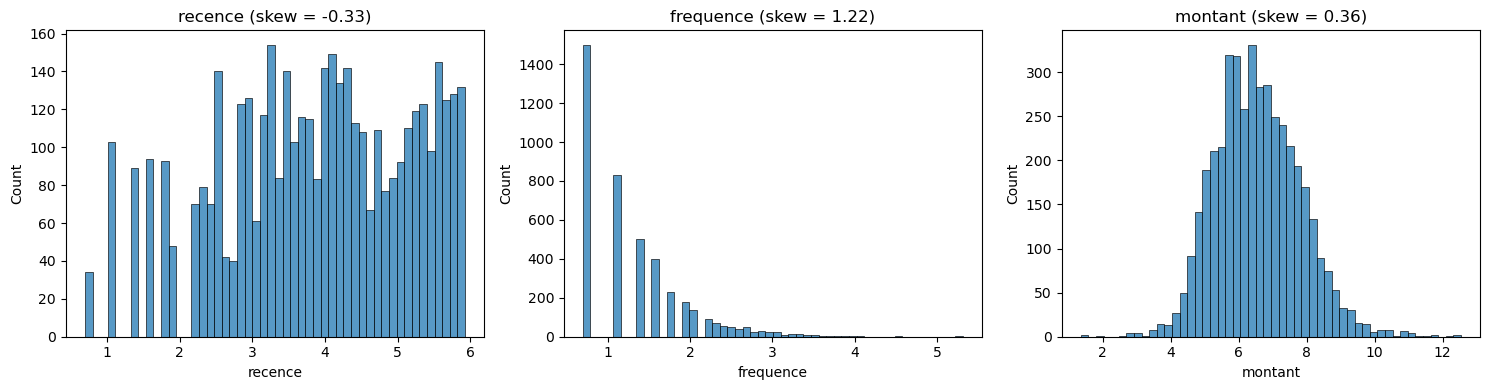

In [52]:
# Mêmes histogrammes qu'en 5.1 mais sur les données transformées, pour comparer le skew avant / après
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["recence", "frequence", "montant"]):
    sns.histplot(rfm_log[col], bins=50, ax=ax)
    ax.set_title(f"{col} (skew = {rfm_log[col].skew():.2f})")

plt.tight_layout()
plt.show()

Le log a fait son travail :
- Le Montant passe d'un skew de 21,65 à 0,36. On a maintenant presque une cloche.
- La Fréquence passe de 11,84 à 1,22. Elle reste un peu asymétrique à cause des 1 500 clients qui n'ont commandé qu'une fois : ils ont tous la même valeur, le log ne peut pas les étaler.
- La Récence passe de 1,24 à -0,33. Elle était déjà peu asymétrique, donc le log l'a fait passer un peu de l'autre côté, mais elle reste dans la zone "quasi symétrique" (entre -0,5 et 0,5).

Pour la Récence le log n'était pas indispensable. J'ai choisi de le faire quand même parce qu'elle est plus proche de la symétrie après (-0,33) qu'avant (1,24).

Les extrêmes ne sont plus à des kilomètres du reste. On peut passer à la standardisation.

## 6. Standardisation

### 6.1 Mise à l'échelle des variables

K-Means et la CAH calculent des distances entre clients. Si une variable a des valeurs plus grandes que les autres, elle pèse plus dans le calcul. On ramène donc les trois variables à la même échelle avec `StandardScaler` (moyenne 0, écart-type 1).

In [53]:
# On standardise les trois variables (moyenne 0, écart-type 1) pour qu'elles pèsent pareil dans les distances
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    index=rfm_log.index,
    columns=rfm_log.columns
)
rfm_scaled.head()

,recence,frequence,montant
id_client,,,
12347,-1.891803,1.087338,1.453638
12348,0.370614,0.396083,0.573320
12349,-0.660626,-0.951547,0.584565
12350,1.440963,-0.951547,-0.696011
12352,-0.169625,0.890947,0.471287


Les trois variables sont maintenant à la même échelle, autour de 0. Positif = au-dessus de la moyenne, négatif = en dessous.

Ex : le client 12347 a une Récence de -1,89, une Fréquence de 1,09 et un Montant de 1,45. Il achète souvent, beaucoup et récemment. Attention, pour la Récence c'est inversé : négatif veut dire qu'il a acheté plus récemment que la moyenne, donc c'est bien.

### 6.2 Vérification

In [55]:
# On vérifie que chaque variable a bien une moyenne de 0 et un écart-type de 1
rfm_scaled.describe().round(2)

,recence,frequence,montant
count,4321.00,4321.00,4321.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.42,-0.95,-4.17
25%,-0.70,-0.95,-0.68
50%,0.07,-0.36,-0.06
75%,0.85,0.66,0.66
max,1.58,5.85,4.80


La moyenne est à 0 et l'écart-type à 1 pour les trois variables. Le -0.00 vient d'un arrondi.

La Fréquence monte jusqu'à 5,85. Les clients qui commandent beaucoup restent visibles mais beaucoup moins éloignés qu'avant le log. Le minimum et le premier quartile de la Fréquence sont identiques (-0,95). Ils correspondent aux clients qui n'ont commandé qu'une seule fois.

Le dataset est prêt pour le clustering.